
# TP3 - Detección del logotipo Coca-Cola

Alumno: Juan Fajardo

Este cuaderno resuelve los 3 ítems del TP 


In [56]:

import os
from pathlib import Path

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['image.cmap'] = 'gray'



## Configuración de rutas

El cuaderno busca los archivos en varias rutas típicas de Colab o de una ejecución local.


In [57]:
from pathlib import Path

# Si el notebook está dentro de TP3, la base es el directorio actual
ruta_base = Path.cwd()

# Carpetas
ruta_imagenes = ruta_base / "images"
ruta_template = ruta_base / "template"

# Nombres de archivos
nombres_imagenes = [
    "coca_logo_1.png",
    "coca_logo_2.png",
    "coca_retro_1.png",
    "coca_retro_2.png",
    "logo_1.png",
    "coca_multi.png",
]

nombre_plantilla = "pattern.png"

# Rutas completas
ruta_plantilla = ruta_template / nombre_plantilla
rutas_imagenes = [ruta_imagenes / nombre for nombre in nombres_imagenes]

# Carpeta de salida
ruta_salida = ruta_base / "salidas_tp3"
ruta_salida.mkdir(parents=True, exist_ok=True)

print("Directorio actual:", ruta_base)
print("Plantilla:", ruta_plantilla)
print("Imágenes:")
for ruta in rutas_imagenes:
    print(" -", ruta)

Directorio actual: /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3
Plantilla: /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/template/pattern.png
Imágenes:
 - /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/images/coca_logo_1.png
 - /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/images/coca_logo_2.png
 - /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/images/coca_retro_1.png
 - /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/images/coca_retro_2.png
 - /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/images/logo_1.png
 - /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/images/coca_multi.png



## Funciones auxiliares

Usamos una versión enmascarada de la plantilla para quedarnos con la curva del logo y reducir el peso del fondo blanco.


In [58]:

def cargar_imagen_color(ruta: Path) -> np.ndarray:
    imagen = cv.imread(str(ruta))
    if imagen is None:
        raise FileNotFoundError(f"No se pudo abrir la imagen: {ruta}")
    return imagen


def a_gris(imagen_bgr: np.ndarray) -> np.ndarray:
    return cv.cvtColor(imagen_bgr, cv.COLOR_BGR2GRAY)


def obtener_bordes(imagen_gris: np.ndarray, umbral1: int = 50, umbral2: int = 150) -> np.ndarray:
    return cv.Canny(imagen_gris, umbral1, umbral2)


def preparar_plantilla(ruta: Path, umbral_blanco: int = 245):
    plantilla_bgr = cv.imread(str(ruta))
    if plantilla_bgr is None:
        raise FileNotFoundError(f"No se pudo abrir la plantilla: {ruta}")

    plantilla_gris = cv.cvtColor(plantilla_bgr, cv.COLOR_BGR2GRAY)

    # Máscara para quedarnos solo con el logo y eliminar el fondo blanco
    mascara_plantilla = (plantilla_gris < umbral_blanco).astype(np.uint8) * 255

    ys, xs = np.where(mascara_plantilla > 0)
    if len(xs) == 0 or len(ys) == 0:
        raise ValueError("La plantilla quedó vacía después del umbral.")

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    plantilla_gris = plantilla_gris[y1:y2 + 1, x1:x2 + 1]
    mascara_plantilla = mascara_plantilla[y1:y2 + 1, x1:x2 + 1]

    plantilla_bordes = obtener_bordes(plantilla_gris)

    return plantilla_gris, plantilla_bordes, mascara_plantilla


plantilla_gris, plantilla_bordes, mascara_plantilla = preparar_plantilla(ruta_plantilla)


def mostrar_imagenes_grid(imagenes, titulos, filas, columnas, figsize=(16, 10)):
    fig, ejes = plt.subplots(filas, columnas, figsize=figsize)
    ejes = np.array(ejes).reshape(-1)

    for eje, imagen, titulo in zip(ejes, imagenes, titulos):
        if imagen.ndim == 2:
            eje.imshow(imagen, cmap="gray")
        else:
            eje.imshow(cv.cvtColor(imagen, cv.COLOR_BGR2RGB))
        eje.set_title(titulo)
        eje.axis("off")

    for eje in ejes[len(imagenes):]:
        eje.axis("off")

    plt.tight_layout()
    plt.show()


def obtener_mascara_roja(imagen_bgr: np.ndarray, saturacion_min=20, valor_min=40, kernel=5) -> np.ndarray:
    hsv = cv.cvtColor(imagen_bgr, cv.COLOR_BGR2HSV)

    mascara = (((hsv[:, :, 0] < 15) | (hsv[:, :, 0] > 165)) &
               (hsv[:, :, 1] > saturacion_min) &
               (hsv[:, :, 2] > valor_min)).astype(np.uint8) * 255

    elemento = cv.getStructuringElement(cv.MORPH_RECT, (kernel, kernel))
    mascara = cv.morphologyEx(mascara, cv.MORPH_OPEN, elemento)
    mascara = cv.morphologyEx(mascara, cv.MORPH_CLOSE, elemento)
    return mascara


def obtener_candidatos_rojos(imagen_bgr: np.ndarray,
                             area_min: int = 1000,
                             relacion_min: float = 0.5,
                             relacion_max: float = 5.0,
                             y_min_rel: float = 0.0,
                             kernel: int = 5,
                             saturacion_min: int = 20,
                             valor_min: int = 40):
    mascara = obtener_mascara_roja(
        imagen_bgr,
        saturacion_min=saturacion_min,
        valor_min=valor_min,
        kernel=kernel
    )

    num_componentes, _, estadisticas, _ = cv.connectedComponentsWithStats(mascara, connectivity=8)

    alto_imagen, ancho_imagen = imagen_bgr.shape[:2]
    y_min = int(alto_imagen * y_min_rel)

    candidatos = []
    for i in range(1, num_componentes):
        x, y, w, h, area = estadisticas[i]
        if h <= 0:
            continue

        relacion = w / h
        if area >= area_min and relacion_min <= relacion <= relacion_max and y >= y_min:
            candidatos.append((int(x), int(y), int(w), int(h), int(area), float(relacion)))

    candidatos.sort(key=lambda c: c[4], reverse=True)
    return candidatos, mascara


def buscar_en_roi(roi_gris: np.ndarray,
                  plantilla_bordes: np.ndarray,
                  mascara_plantilla: np.ndarray,
                  escalas=np.linspace(0.4, 1.8, 29)):
    mejor = {
        "score": -1.0,
        "escala": None,
        "ubicacion": None,
        "tamano": None,
    }

    roi_bordes = obtener_bordes(roi_gris)

    for escala in escalas:
        plantilla_escalada = cv.resize(
            plantilla_bordes,
            None,
            fx=float(escala),
            fy=float(escala),
            interpolation=cv.INTER_AREA if escala < 1 else cv.INTER_CUBIC,
        )
        mascara_escalada = cv.resize(
            mascara_plantilla,
            None,
            fx=float(escala),
            fy=float(escala),
            interpolation=cv.INTER_NEAREST,
        )

        if (plantilla_escalada.shape[0] >= roi_bordes.shape[0] or
            plantilla_escalada.shape[1] >= roi_bordes.shape[1] or
            plantilla_escalada.shape[0] < 10 or
            plantilla_escalada.shape[1] < 10):
            continue

        respuesta = cv.matchTemplate(
            roi_bordes,
            plantilla_escalada,
            cv.TM_CCORR_NORMED,
            mask=mascara_escalada
        )

        respuesta = np.where(np.isfinite(respuesta), respuesta, -1)
        _, max_valor, _, max_loc = cv.minMaxLoc(respuesta)

        if max_valor > mejor["score"]:
            mejor["score"] = float(max_valor)
            mejor["escala"] = float(escala)
            mejor["ubicacion"] = (int(max_loc[0]), int(max_loc[1]))
            mejor["tamano"] = (int(plantilla_escalada.shape[1]), int(plantilla_escalada.shape[0]))

    return mejor


def buscar_en_imagen_completa(imagen_gris: np.ndarray,
                              plantilla_bordes: np.ndarray,
                              mascara_plantilla: np.ndarray,
                              escalas=np.linspace(0.4, 2.0, 33)):
    mejor = {
        "score": -1.0,
        "escala": None,
        "ubicacion": None,
        "tamano": None,
    }

    imagen_bordes = obtener_bordes(imagen_gris)

    for escala in escalas:
        plantilla_escalada = cv.resize(
            plantilla_bordes,
            None,
            fx=float(escala),
            fy=float(escala),
            interpolation=cv.INTER_AREA if escala < 1 else cv.INTER_CUBIC,
        )
        mascara_escalada = cv.resize(
            mascara_plantilla,
            None,
            fx=float(escala),
            fy=float(escala),
            interpolation=cv.INTER_NEAREST,
        )

        if (plantilla_escalada.shape[0] >= imagen_bordes.shape[0] or
            plantilla_escalada.shape[1] >= imagen_bordes.shape[1] or
            plantilla_escalada.shape[0] < 10 or
            plantilla_escalada.shape[1] < 10):
            continue

        respuesta = cv.matchTemplate(
            imagen_bordes,
            plantilla_escalada,
            cv.TM_CCORR_NORMED,
            mask=mascara_escalada
        )

        respuesta = np.where(np.isfinite(respuesta), respuesta, -1)
        _, max_valor, _, max_loc = cv.minMaxLoc(respuesta)

        if max_valor > mejor["score"]:
            mejor["score"] = float(max_valor)
            mejor["escala"] = float(escala)
            mejor["ubicacion"] = (int(max_loc[0]), int(max_loc[1]))
            mejor["tamano"] = (int(plantilla_escalada.shape[1]), int(plantilla_escalada.shape[0]))

    return mejor


def iou(caja_a, caja_b):
    x1 = max(caja_a[0], caja_b[0])
    y1 = max(caja_a[1], caja_b[1])
    x2 = min(caja_a[2], caja_b[2])
    y2 = min(caja_a[3], caja_b[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (caja_a[2] - caja_a[0]) * (caja_a[3] - caja_a[1])
    area_b = (caja_b[2] - caja_b[0]) * (caja_b[3] - caja_b[1])
    union = area_a + area_b - inter + 1e-9
    return inter / union


def aplicar_nms(detecciones, umbral_iou=0.2):
    if not detecciones:
        return []

    indices = np.argsort([-d["score"] for d in detecciones])
    detecciones = [detecciones[i] for i in indices]
    seleccionadas = []

    while detecciones:
        mejor = detecciones.pop(0)
        seleccionadas.append(mejor)
        detecciones = [
            d for d in detecciones
            if iou(
                (mejor["x1"], mejor["y1"], mejor["x2"], mejor["y2"]),
                (d["x1"], d["y1"], d["x2"], d["y2"])
            ) < umbral_iou
        ]

    return seleccionadas


def dibujar_detecciones(imagen_bgr: np.ndarray, detecciones, color=(0, 255, 0)):
    salida = imagen_bgr.copy()

    for det in detecciones:
        x1, y1, x2, y2 = det["x1"], det["y1"], det["x2"], det["y2"]
        cv.rectangle(salida, (x1, y1), (x2, y2), color, 2)
        etiqueta = f"{det['score']:.2f}"
        cv.putText(salida, etiqueta, (x1, max(0, y1 - 5)),
                   cv.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv.LINE_AA)

    return salida


## Ítem 1

Una detección por imagen, evitando falsos positivos.

Estrategia:
Se implementó un esquema de detección jerárquico en dos etapas. Primero, se segmentaron regiones candidatas en el espacio HSV buscando tonos rojos compatibles con las etiquetas del logo, y sobre esas ROIs se aplicó template matching usando la plantilla procesada en bordes. Esta búsqueda local reduce el espacio de exploración y ayuda a evitar falsos positivos, porque el algoritmo no compara la plantilla contra toda la imagen sino solo contra zonas con mayor probabilidad de contener el logotipo. Luego, se agregó un padding alrededor de cada ROI para no perder partes del logo por recortes demasiado ajustados.

Como respaldo, se incorporó un fallback global sobre toda la imagen, también en bordes, para los casos en que la segmentación por color no sea suficiente o no encuentre una ROI confiable. La decisión final se toma según la mejor confianza obtenida, priorizando la coincidencia con mayor score. De este modo, el método combina precisión local con robustez global, logrando una detección principal en cada imagen sin depender exclusivamente del color ni de una única región candidata.


In [59]:

def detectar_logo_principal(imagen_bgr: np.ndarray,
                            confianza_minima_roi=0.38,
                            confianza_minima_fallback=0.25,
                            padding=20):

    imagen_gris = a_gris(imagen_bgr)

    candidatos, _ = obtener_candidatos_rojos(
        imagen_bgr,
        area_min=800,
        relacion_min=0.4,
        relacion_max=6.0,
        y_min_rel=0.0,
        kernel=5,
        saturacion_min=15,
        valor_min=30,
    )

    mejor = None

    #  1. Buscar en ROIs (más candidatos + padding)
    for x, y, w, h, _, _ in candidatos[:12]:

        x0 = max(0, x - padding)
        y0 = max(0, y - padding)
        x1 = min(imagen_gris.shape[1], x + w + padding)
        y1 = min(imagen_gris.shape[0], y + h + padding)

        roi_gris = imagen_gris[y0:y1, x0:x1]

        resultado = buscar_en_roi(roi_gris, plantilla_bordes, mascara_plantilla)

        if resultado["ubicacion"] is None:
            continue

        lx, ly = resultado["ubicacion"]
        tw, th = resultado["tamano"]

        score = resultado["score"]

        if mejor is None or score > mejor["score"]:
            mejor = {
                "x1": x0 + lx,
                "y1": y0 + ly,
                "x2": x0 + lx + tw,
                "y2": y0 + ly + th,
                "score": score,
                "escala": resultado["escala"],
                "metodo": "roi_color_bordes",
            }

    #  Si ROI fue suficientemente buena 
    if mejor is not None and mejor["score"] >= confianza_minima_roi:
        return mejor

    # Fallback global (bordes)
    resultado = buscar_en_imagen_completa(imagen_gris, plantilla_bordes, mascara_plantilla)

    if resultado["ubicacion"] is not None:
        x, y = resultado["ubicacion"]
        tw, th = resultado["tamano"]

        fallback = {
            "x1": x,
            "y1": y,
            "x2": x + tw,
            "y2": y + th,
            "score": resultado["score"],
            "escala": resultado["escala"],
            "metodo": "fallback_bordes",
        }

        # Si fallback es mejor usarlo
        if mejor is None or fallback["score"] > mejor["score"]:
            mejor = fallback

    # Última garantía: nunca devolver None
    return mejor


resultados_item1 = []
for ruta in rutas_imagenes:
    imagen = cargar_imagen_color(ruta)
    deteccion = detectar_logo_principal(imagen)
    resultados_item1.append((ruta.name, deteccion))
    print(ruta.name, "->", deteccion)

coca_logo_1.png -> {'x1': 30, 'y1': 208, 'x2': 199, 'y2': 262, 'score': 0.453750342130661, 'escala': 0.45, 'metodo': 'roi_color_bordes'}
coca_logo_2.png -> {'x1': 51, 'y1': 113, 'x2': 201, 'y2': 161, 'score': 0.41167524456977844, 'escala': 0.4, 'metodo': 'roi_color_bordes'}
coca_retro_1.png -> {'x1': 352, 'y1': 356, 'x2': 502, 'y2': 404, 'score': 0.3878163695335388, 'escala': 0.4, 'metodo': 'fallback_bordes'}
coca_retro_2.png -> {'x1': 60, 'y1': 196, 'x2': 210, 'y2': 244, 'score': 0.47956594824790955, 'escala': 0.4, 'metodo': 'roi_color_bordes'}
logo_1.png -> {'x1': 277, 'y1': 225, 'x2': 446, 'y2': 279, 'score': 0.32535240054130554, 'escala': 0.45, 'metodo': 'roi_color_bordes'}
coca_multi.png -> {'x1': 390, 'y1': 156, 'x2': 540, 'y2': 204, 'score': 0.39491498470306396, 'escala': 0.4, 'metodo': 'roi_color_bordes'}


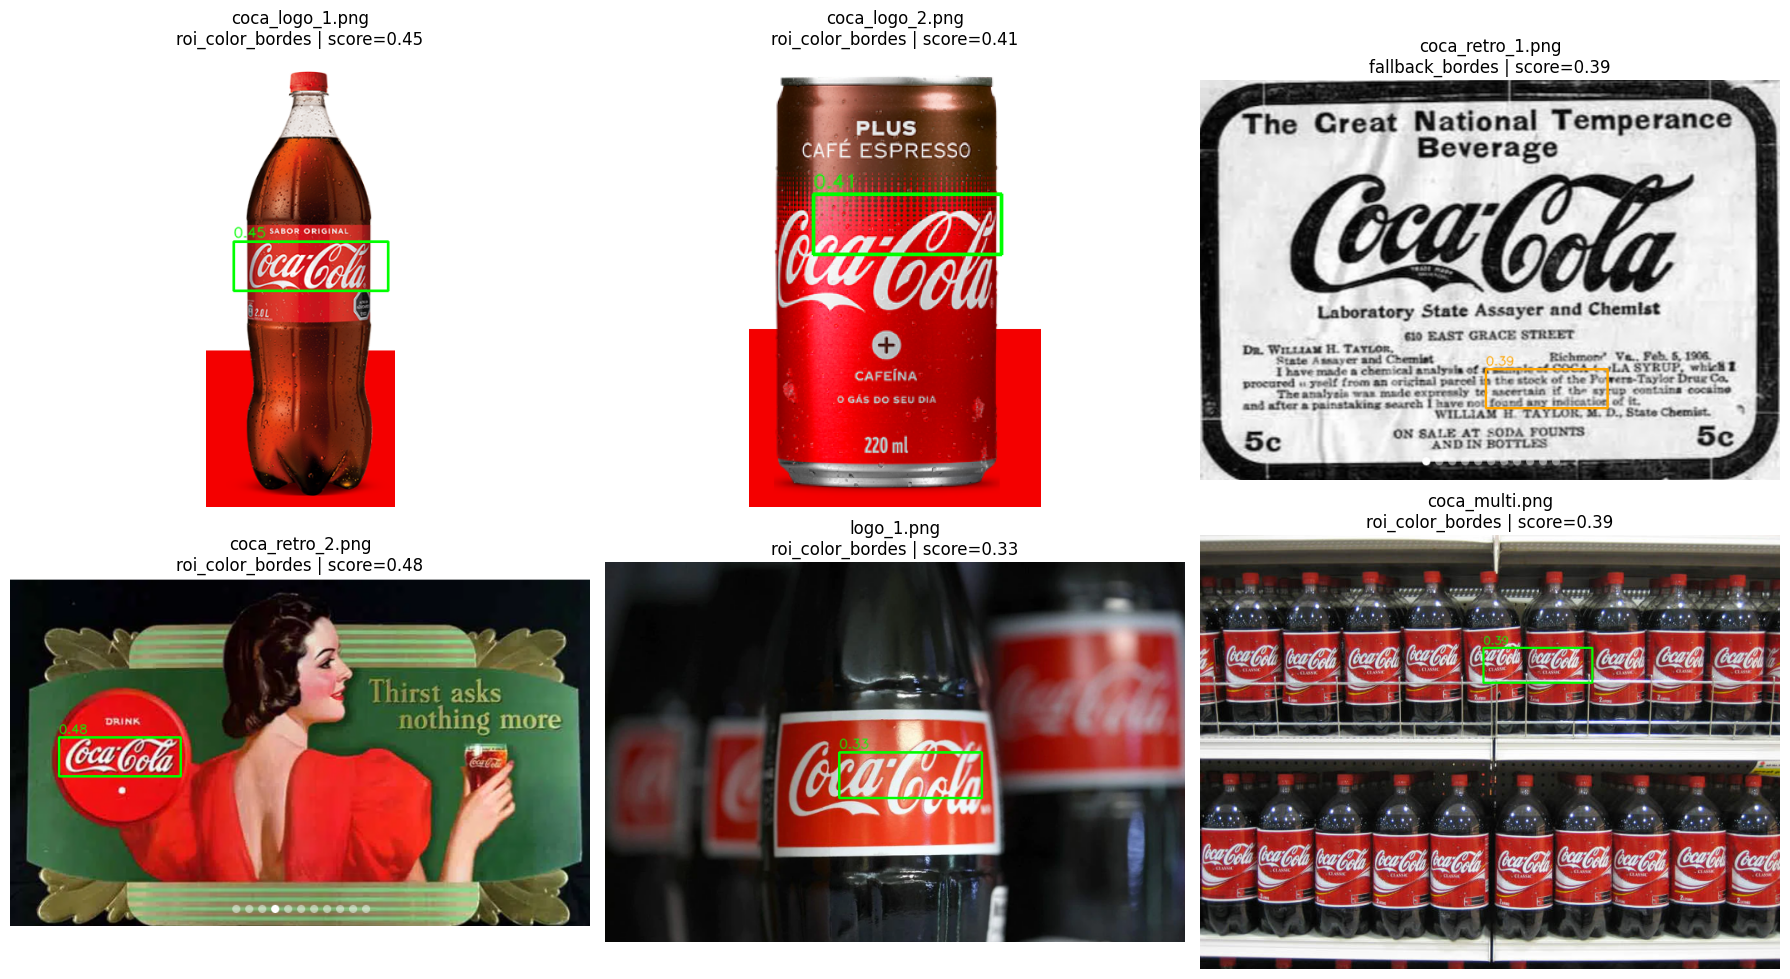

In [60]:

imagenes_mostradas = []
titulos_mostrados = []

for ruta in rutas_imagenes:
    imagen = cargar_imagen_color(ruta)
    deteccion = detectar_logo_principal(imagen)

    imagen_annotada = imagen.copy()

    if deteccion is not None:
        # Color según método (debug visual útil)
        if "roi" in deteccion["metodo"]:
            color = (0, 255, 0)  # verde
        else:
            color = (0, 165, 255)  # naranja (fallback)

        imagen_annotada = dibujar_detecciones(imagen_annotada, [deteccion], color=color)

        titulo = f"{ruta.name}\n{deteccion['metodo']} | score={deteccion['score']:.2f}"
    else:
        titulo = f"{ruta.name}\nSIN DETECCIÓN"

    imagenes_mostradas.append(imagen_annotada)
    titulos_mostrados.append(titulo)

mostrar_imagenes_grid(
    imagenes_mostradas,
    titulos_mostrados,
    filas=2,
    columnas=3,
    figsize=(18, 10)
)


## Ítem 2

Múltiples detecciones en `coca_multi.png` usando la misma plantilla.

Se implementó una estrategia de detección múltiple basada en dos etapas. Primero, se segmentaron las regiones rojas de la imagen en el espacio HSV para obtener candidatos plausibles donde podría aparecer el logotipo. Sobre cada componente conectado se aplicó un filtro por área, relación de aspecto y posición vertical, con el objetivo de descartar regiones que no correspondieran a etiquetas de botellas o latas, como estanterías o bordes de la góndola. Luego, sobre cada ROI seleccionada, se ejecutó template matching con la plantilla procesada en bordes y en varias escalas, permitiendo detectar instancias del logo con distinto tamaño.

Para evitar duplicaciones entre detecciones cercanas, se aplicó Non-Maximum Suppression (NMS) usando IoU como criterio de solapamiento. Esto permitió conservar solo las coincidencias más confiables y eliminar respuestas redundantes generadas sobre una misma etiqueta. La combinación de segmentación por color, búsqueda multi-escala y NMS hizo posible localizar varias instancias del logotipo en una misma imagen, manteniendo un buen equilibrio entre recall y control de falsos positivos.


In [61]:
def detectar_logos_multiples(imagen_bgr: np.ndarray):
    alto, ancho = imagen_bgr.shape[:2]
    imagen_gris = a_gris(imagen_bgr)

    hsv = cv.cvtColor(imagen_bgr, cv.COLOR_BGR2HSV)
    mascara = (((hsv[:, :, 0] < 15) | (hsv[:, :, 0] > 165)) &
               (hsv[:, :, 1] > 35) &
               (hsv[:, :, 2] > 30)).astype(np.uint8) * 255

    if alto > 1000:
        elemento = cv.getStructuringElement(cv.MORPH_RECT, (11, 11))
        mascara = cv.morphologyEx(mascara, cv.MORPH_OPEN, elemento)
        mascara = cv.morphologyEx(mascara, cv.MORPH_CLOSE, elemento)
        area_min = 5000
        y_min = int(alto * 0.25)   # antes 0.10
    else:
        elemento = cv.getStructuringElement(cv.MORPH_RECT, (5, 5))
        mascara = cv.morphologyEx(mascara, cv.MORPH_OPEN, elemento)
        mascara = cv.morphologyEx(mascara, cv.MORPH_CLOSE, elemento)
        area_min = 800
        y_min = 0

    num_componentes, _, estadisticas, _ = cv.connectedComponentsWithStats(mascara, connectivity=8)

    detecciones = []

    for i in range(1, num_componentes):
        x, y, w, h, area = estadisticas[i]
        if h <= 0:
            continue

        relacion = w / h

        # Más restrictivo para evitar estanterías largas y falsas ROIs
        if not (area >= area_min and relacion >= 1.4 and y >= y_min):
            continue

        pad = 20
        x0 = max(0, x - pad)
        y0 = max(0, y - pad)
        x1 = min(ancho, x + w + pad)
        y1 = min(alto, y + h + pad)

        roi = imagen_gris[y0:y1, x0:x1]

        resultado = buscar_en_roi(
            roi,
            plantilla_bordes,
            mascara_plantilla,
            escalas=np.linspace(0.25, 1.00, 20)
        )

        if resultado["ubicacion"] is None:
            continue

        if resultado["score"] < 0.45:
            continue

        lx, ly = resultado["ubicacion"]
        tw, th = resultado["tamano"]

        detecciones.append({
            "x1": int(x0 + lx),
            "y1": int(y0 + ly),
            "x2": int(x0 + lx + tw),
            "y2": int(y0 + ly + th),
            "score": float(resultado["score"]),
            "escala": float(resultado["escala"]),
        })

    detecciones = aplicar_nms(detecciones, umbral_iou=0.15)
    detecciones.sort(key=lambda d: d["score"], reverse=True)
    return detecciones

Cantidad de detecciones: 3
{'x1': 273, 'y1': 153, 'x2': 367, 'y2': 183, 'score': 0.5301619172096252, 'escala': 0.25}
{'x1': 484, 'y1': 430, 'x2': 578, 'y2': 460, 'score': 0.5203678011894226, 'escala': 0.25}
{'x1': 69, 'y1': 428, 'x2': 163, 'y2': 458, 'score': 0.518822193145752, 'escala': 0.25}


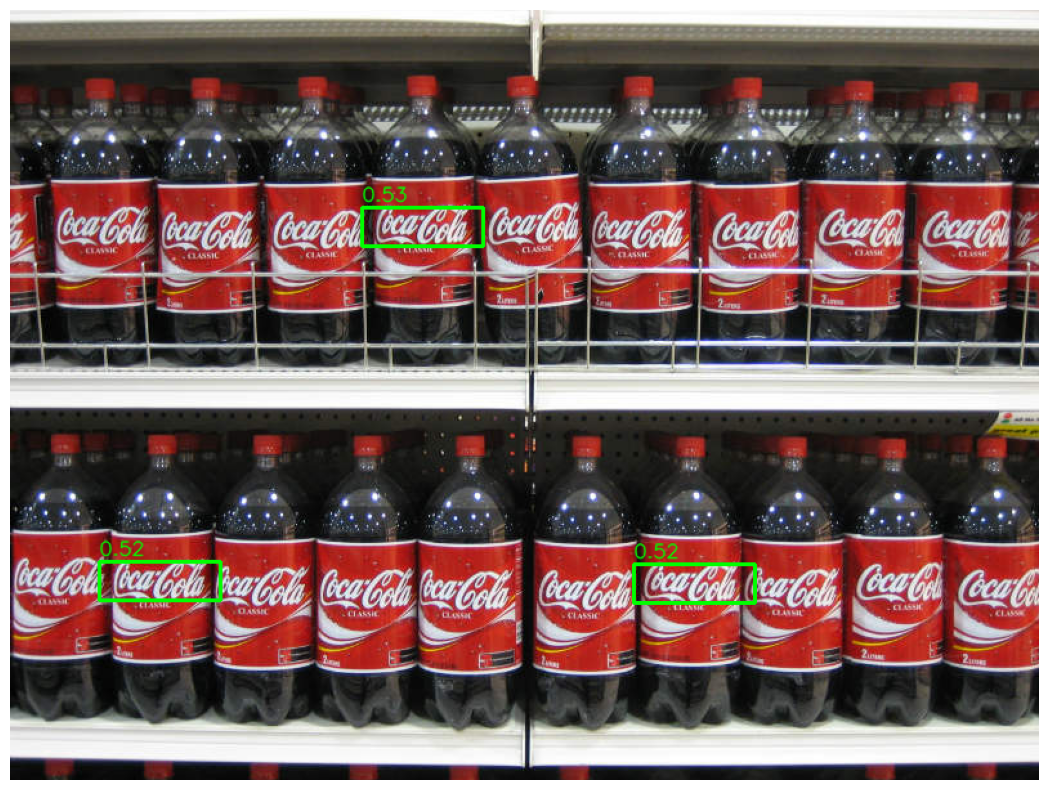

In [62]:
imagen_multi = cargar_imagen_color(rutas_imagenes[5])
detecciones_multi = detectar_logos_multiples(imagen_multi)

print("Cantidad de detecciones:", len(detecciones_multi))
for d in detecciones_multi:
    print(d)

imagen_multi_annotada = dibujar_detecciones(imagen_multi, detecciones_multi)
plt.figure(figsize=(14, 10))
plt.imshow(cv.cvtColor(imagen_multi_annotada, cv.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


## Ítem 3

Generalizamos el algoritmo del ítem 2 para todo el conjunto de imágenes y guardamos las salidas en una carpeta local.


coca_logo_1.png: 1 detecciones -> /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/salidas_tp3/coca_logo_1_deteccion.png
coca_logo_2.png: 1 detecciones -> /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/salidas_tp3/coca_logo_2_deteccion.png
coca_retro_1.png: 1 detecciones -> /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/salidas_tp3/coca_retro_1_deteccion.png
coca_retro_2.png: 1 detecciones -> /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/salidas_tp3/coca_retro_2_deteccion.png
logo_1.png: 1 detecciones -> /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/salidas_tp3/logo_1_deteccion.png
coca_multi.png: 3 detecciones -> /Users/juan.fajardo/IA Master program/vision_computadora_I/Material_TPs/TP3/salidas_tp3/coca_multi_deteccion.png


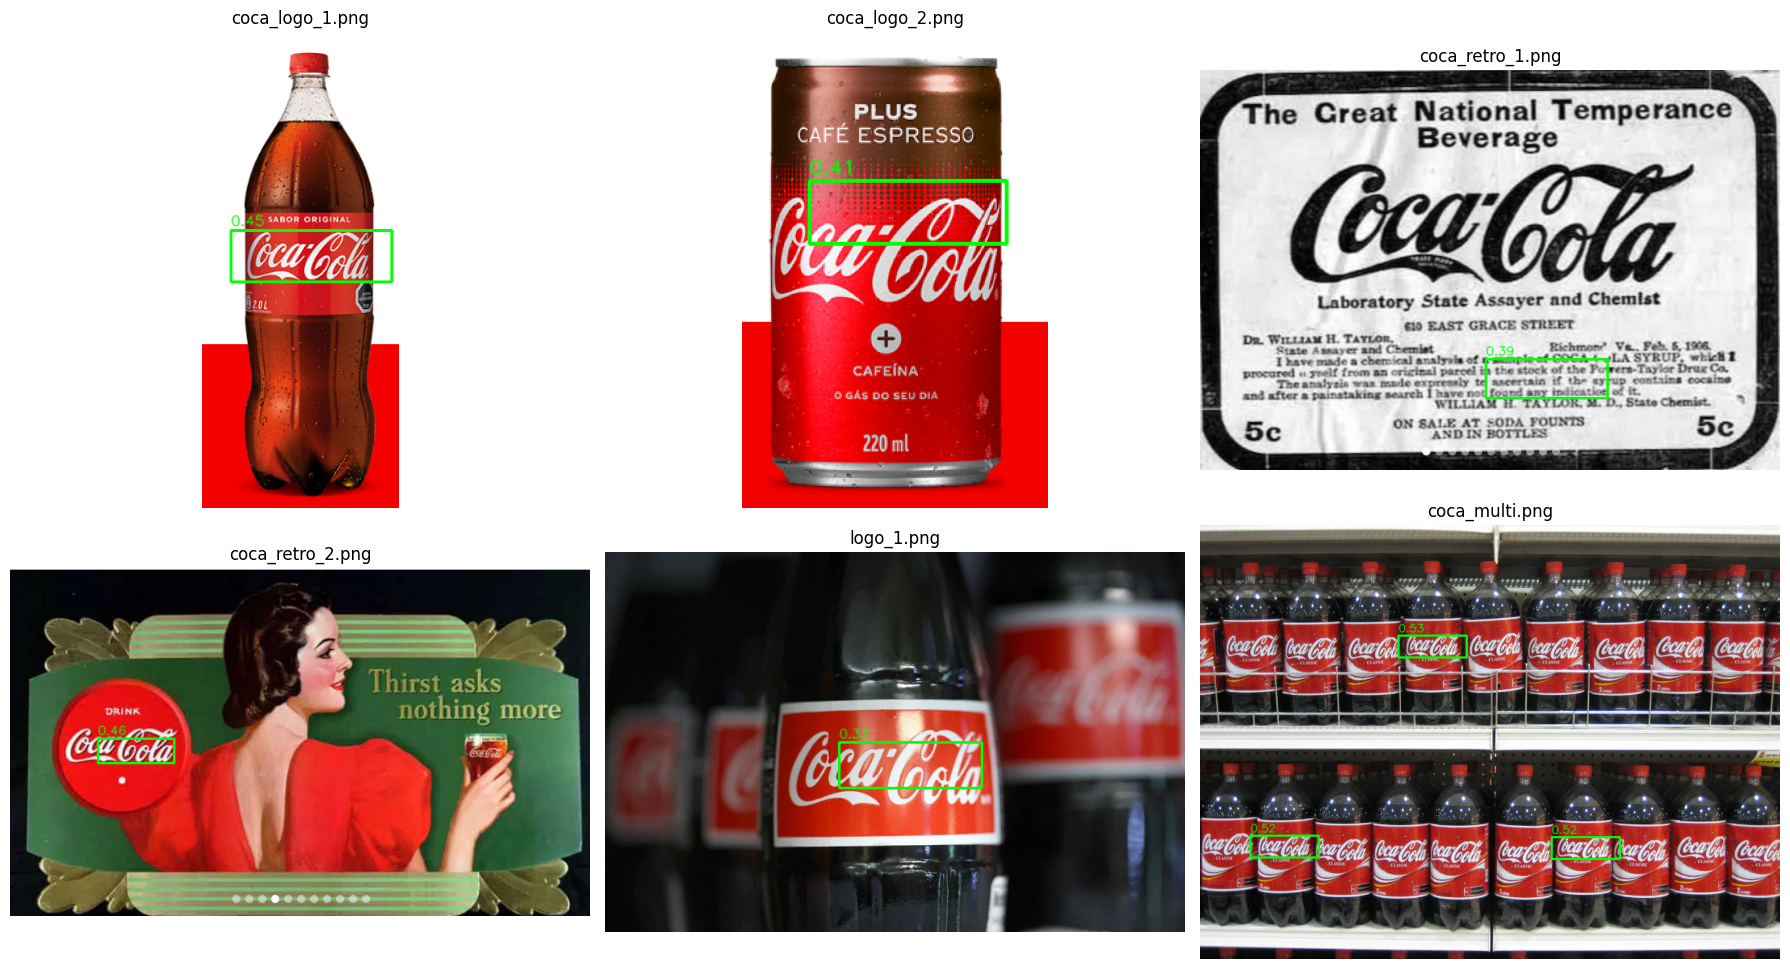

In [63]:

resumen = []
for ruta in rutas_imagenes:
    imagen = cargar_imagen_color(ruta)
    detecciones = detectar_logos_multiples(imagen)

    if len(detecciones) == 0:
        deteccion = detectar_logo_principal(imagen)
        detecciones = [] if deteccion is None else [deteccion]

    imagen_annotada = dibujar_detecciones(imagen, detecciones)
    ruta_salida_imagen = ruta_salida / f'{ruta.stem}_deteccion.png'
    cv.imwrite(str(ruta_salida_imagen), imagen_annotada)
    resumen.append((ruta.name, len(detecciones), str(ruta_salida_imagen)))

for nombre, cantidad, ruta_guardada in resumen:
    print(f'{nombre}: {cantidad} detecciones -> {ruta_guardada}')

# Vista rápida de los resultados guardados.
imagenes_finales = []
titulos_finales = []
for nombre, _, ruta_guardada in resumen:
    img = cv.imread(ruta_guardada)
    imagenes_finales.append(img)
    titulos_finales.append(nombre)

mostrar_imagenes_grid(imagenes_finales, titulos_finales, filas=2, columnas=3, figsize=(18, 10))


### Análisis de resultados

Se implementó un algoritmo de detección basado en template matching combinado con una etapa previa de segmentación por color en el espacio HSV para restringir la búsqueda a regiones candidatas. En el ítem 1, la estrategia permitió detectar correctamente el logotipo en todas las imágenes, aunque con cierta variabilidad en el nivel de confianza debido a diferencias de escala, iluminación y deformaciones del logo (por ejemplo, en superficies curvas como botellas y latas). En el ítem 2, para la imagen con múltiples instancias (coca_multi.png), se utilizó la segmentación por color para separar las etiquetas y luego se aplicó template matching en cada ROI, complementado con Non-Maximum Suppression (NMS) para eliminar detecciones redundantes. Esto permitió detectar múltiples logos de manera consistente, aunque no exhaustiva.

La combinación de segmentación por color y template matching resulta efectiva para reducir falsos positivos y mejorar la eficiencia, ya que limita la búsqueda a regiones relevantes. Sin embargo, el método presenta limitaciones importantes: no es invariante a cambios significativos de escala, perspectiva o deformaciones del logo, y puede fallar en condiciones donde el color no es un buen discriminante o donde el fondo presenta patrones similares. En el ítem 3, al generalizar el algoritmo a todas las imágenes, se observó que el uso de un fallback global permite asegurar detecciones en todos los casos, pero con menor precisión. Como mejora futura, podrían incorporarse técnicas más robustas como pirámides de escala, descriptores locales (SIFT/ORB) o métodos basados en aprendizaje profundo para lograr mayor invariancia y precisión.